<big><big>001: data pre-processing walkthrough</big></big>
<a id='index'></a><br>

- [part 0: pre-processing for a single object](#steps)
    - [alert processor](#alertp)
    - [photometry processor](#photo)
    - [data preprocessor](#pre)
    - [images](#images)
    - [alert selection](#alert)
    - [spectra](#spectra)
- [part 1: pre-processing a dataset](#transient)

In [1]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/Users/junell/Documents/AppleCider')

from AppleCider.preprocess.data_preprocessor import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from AppleCider.preprocess.data_preprocessor import DataSorter
from AppleCider.preprocess.transient_dataset import TransientDataset

import AppleCider.preprocess.plot_data as plot_data

In [2]:
SEDM_dataset = pd.read_csv('/Users/junell/Documents/AppleCider/SEDM_dataset.csv')
SEDM_dataset

,obj_id,type
0,ZTF18aatfxtd,SN Ia
1,ZTF18aawppyt,SN Ia
2,ZTF18aakpnyt,AGN
3,ZTF18aclgopa,AGN
4,ZTF18adjoimi,AGN
...,...,...
7493,ZTF18aajlxao,AGN
7494,ZTF18abmwqkr,AGN
7495,ZTF19aadzgnt,AGN
7496,ZTF19aaesrrd,AGN


<big>part 0: pre-processing for a single object</big>

<br>
<i>a) alert processor, b) photometry processor</i>

<a id='steps'></a>
<a id='alertp'></a>
<a id='photo'></a><br>
<i><small>[back to index](#index)</small></i>

In [3]:
obj_SN = 'ZTF20aambbfn'  # other cute SN Ia: ZTF20aarasxl, ZTF20aafjjqj, ZTF22abtbijr
data_dir = '/Users/junell/Documents/AppleCider_Data/SEDM_folder'

## loading data from folder
## change column names, add object id, object type to make photo_df
photo_df = PhotometryProcessor.process_csv(obj_SN, SEDM_dataset, data_dir)
metadata_df, images = AlertProcessor.get_process_alerts(obj_SN, data_dir)

In [4]:
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia
1,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia


In [5]:
metadata_df[:2]

,jd,fid,pid,diffmaglim,pdiffimfilename,programpi,programid,candid,isdiffpos,tblid,...,clrmed,clrrms,neargaia,neargaiabright,maggaia,maggaiabright,exptime,drb,drbversion,obj_id
0,2.458885e+06,2,1130489363715,19.866436,ztf_20200205489340_000752_zr_c10_o_q2_scimrefd...,Kulkarni,3,1130489363715015004,t,4,...,0.742,0.327286,0.976307,-999.0,18.066233,-999.0,30.0,0.996355,d6_m7,ZTF20aambbfn
1,2.458887e+06,1,1132243023715,19.475851,ztf_20200207243021_000752_zg_c10_o_q2_scimrefd...,Kulkarni,1,1132243023715015001,t,1,...,0.601,0.294263,1.226615,-999.0,18.066233,-999.0,30.0,0.976252,d6_m7,ZTF20aambbfn


In [6]:
## sort by date (JD)
## add metadata missing from photometry
photo_df, metadata_df = photo_df.sort_values(by='jd'), metadata_df.sort_values(by='jd')
photo_df = PhotometryProcessor.add_metadata_to_photometry(photo_df, metadata_df)
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia
1,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia


BUUUUT, these give us the full light curve and all the images. we only want the early alerts....

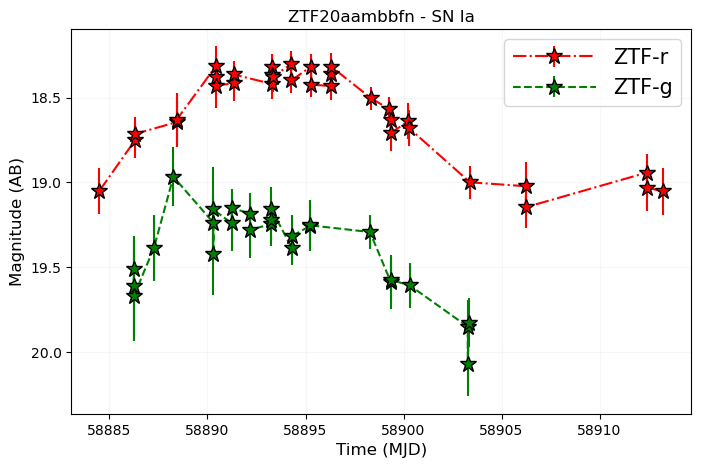

In [7]:
plot_data.plot_photometry_magnitude(photo_df)

<i>c) images</i>

<a id='images'></a>
<i><small>[back to index](#index)</small></i>

55
Selected index: [ 3 54]
Image number: 3


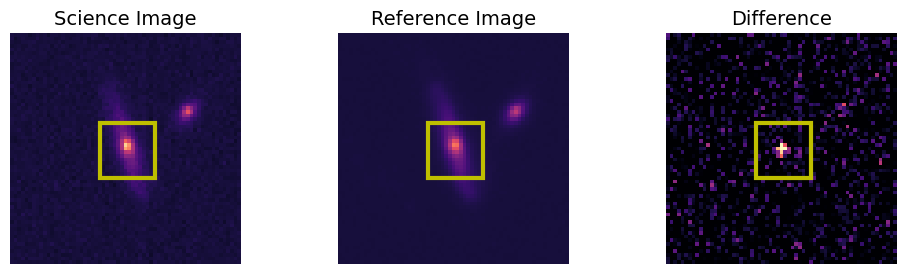

Image number: 54


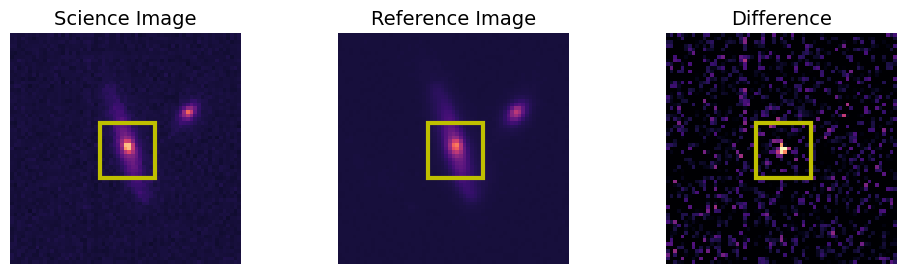

In [8]:
print(len(images))

n = 2
selected_index = np.round(np.linspace(3, len(images) - 1, n)).astype(int)
print('Selected index:', selected_index)
for i in selected_index:
    print('Image number:', i)
    plot_data.plot_image(images[i], vmin_set=0.004, vmax_set=0.099)

<i>d) data preprocessor</i>

<a id='pre'></a>
<i><small>[back to index](#index)</small></i>

In [9]:
## convert magnitude to flux
photo_df = DataPreprocessor.convert_photometry(photo_df)
photo_df[:1]

,obj_id,mjd,flux,flux_error,filter,type,jd
0,ZTF20aambbfn,0.0,87.184596,10.781477,ztfr,SN Ia,2.458885e+06


In [10]:
## cut down to only early-ish photometry
max_ = min(photo_df['mjd'].max(), 10)
photo_df = photo_df[photo_df['mjd'] <= max_]
photo_df[:2]

,obj_id,mjd,flux,flux_error,filter,type,jd
0,ZTF20aambbfn,0.000000,87.184596,10.781477,ztfr,SN Ia,2.458885e+06
1,ZTF20aambbfn,1.752766,51.946980,13.667336,ztfg,SN Ia,2.458887e+06


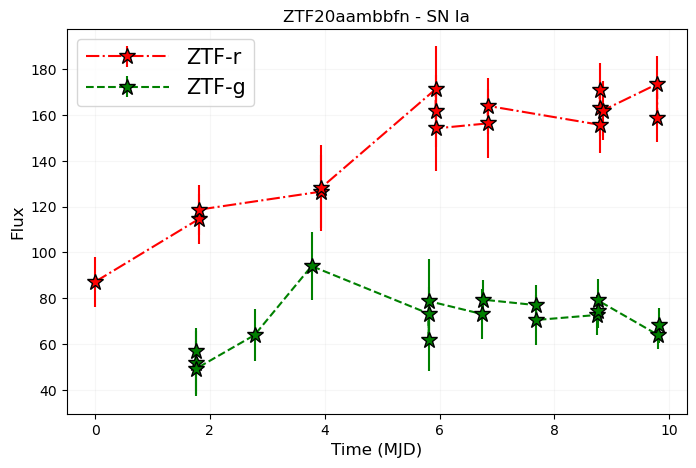

In [11]:
plot_data.plot_photometry_magnitude(photo_df)

<a id='alert'></a><br>

<i>e) alert selection<i>

we'll create some faux alerts by taking valid indices in `metadata_df` and then use them to match the photometry, metadata, and images to the correct time

<i><small>[back to index](#index)</small></i>

In [12]:
metadata_df = metadata_df[metadata_df['jd'] <= photo_df['jd'].max()]
metadata_df = DataPreprocessor.preprocess_metadata(metadata_df)
metadata_df_norm = metadata_df.drop(columns=['jd'])

## and we will slice this into "alerts" 
alert_indices = list(range(len(metadata_df) // 2, len(metadata_df))) 
print("valid alert indices: ", alert_indices, '\n')

## but 15 slices of one object's light curve seems steep, so let's reduce the alerts
if len(alert_indices) > 3:
    alert_indices = np.round(np.linspace(len(metadata_df) // 2, len(metadata_df) - 1, 4)).astype(int)

print("our faux alert indices will be: ", alert_indices)

valid alert indices:  [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28] 

our faux alert indices will be:  [14 19 23 28]


Photometry at index: 14


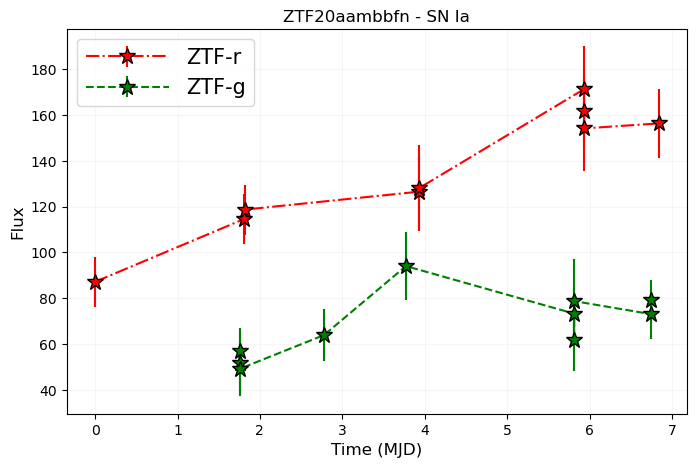

Photometry at index: 19


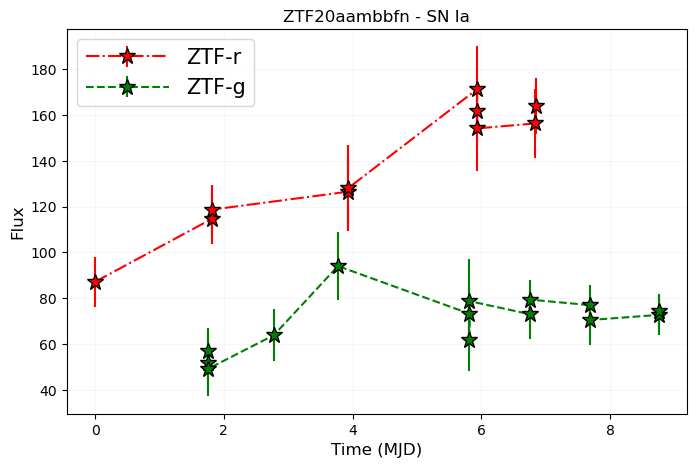

Photometry at index: 23


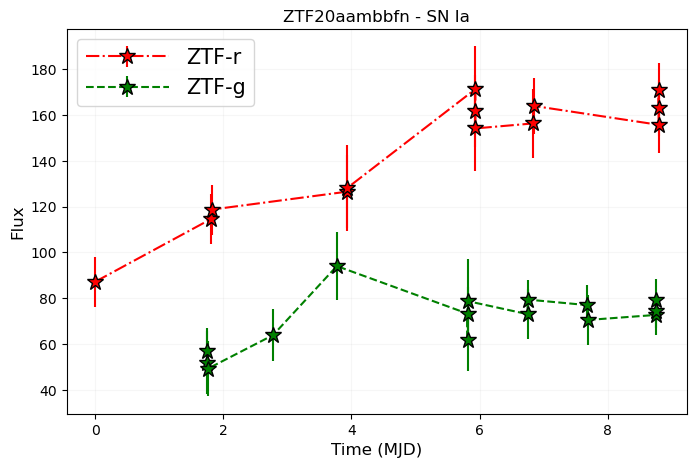

Photometry at index: 28


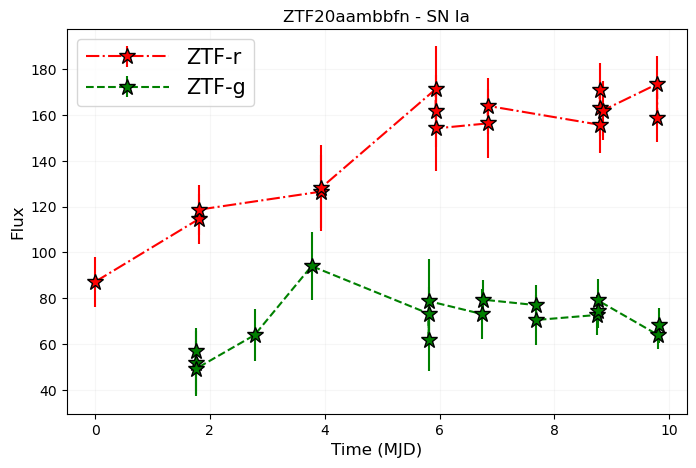

In [13]:
for i in alert_indices:
    print('Photometry at index:', i)
    photo_ready = DataPreprocessor.cut_photometry(photo_df, metadata_df, i, max_mjd=10)
    plot_data.plot_photometry_magnitude(photo_ready)

<i>f) spectra</i>

<a id='spectra'></a>

<i><small>[back to index](#index)</small></i>

In [14]:
SpectraProcessor.get_spectra_df(obj_SN, data_dir)

,ZTFID,wavelength,flux,observed_at,observed_at_mjd,instrument_name,telescope_name,data_length
0,ZTF20aambbfn,3776.7,4.792000e-17,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
1,ZTF20aambbfn,3802.3,4.812000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
2,ZTF20aambbfn,3827.9,7.101000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
3,ZTF20aambbfn,3853.4,4.830000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
4,ZTF20aambbfn,3879.0,5.129000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
...,...,...,...,...,...,...,...,...
209,ZTF20aambbfn,9121.0,1.317000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
210,ZTF20aambbfn,9146.6,1.373000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
211,ZTF20aambbfn,9172.1,1.368000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
212,ZTF20aambbfn,9197.7,1.330000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3


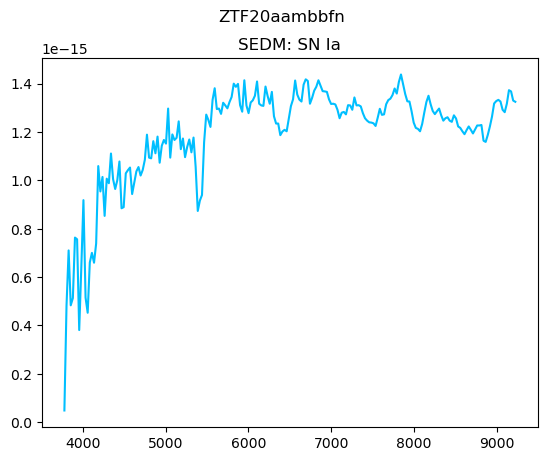

In [15]:
plot_data.plot_spectra(obj_SN, SEDM_dataset, data_dir)

In [16]:
## preprocess spectra
spectra = SpectraProcessor.read_spectra_csv(obj_SN, data_dir)
spectra = SpectraProcessor.preprocess_spectra(spectra)
spectra

array([[-5.152986  , -5.06692   , -4.9808536 , ...,  0.24690495,
         0.21799059,  0.18907624]], dtype=float32)

***

<big><big>part 1: pre-processing the dataset</big></big>

<a id='transient'></a>
<i><small>[back to index](#index)</small></i>

In [17]:
TEST_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_test'
TRAIN_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_train'

CLASSES = ['SN Ia','SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']

SEDM_dataset = SEDM_dataset[SEDM_dataset['type'].isin(CLASSES)]
SEDM_dataset['type'].value_counts()

type
SN Ia                     4982
SN II                      509
SN IIP                     474
Cataclysmic                298
AGN                        180
SN IIn                     168
SN Ic                      116
SN Ib                      110
SN IIb                      85
Tidal Disruption Event      42
Name: count, dtype: int64

In [18]:
## only get to say sedm_spec_only=False since we already filtered out the non-SEDM spectra
test_df, train_df = DataSorter.sample_objects_from_df(SEDM_dataset, 'type', CLASSES, data_dir, n_test=335, n_train=2230,
                                                      sedm_spec_only=False, downsample_SNIa=True)


In [ ]:
test_df = pd.read_csv('/Users/junell/Documents/AppleCider/test_df.csv')
test_df = pd.read_csv('/Users/junell/Documents/AppleCider/train_df.csv')

In [19]:
test_df['type'].value_counts()

type
SN Ia                     77
SN IIP                    74
SN II                     71
Cataclysmic               35
AGN                       22
SN Ic                     22
SN IIn                    20
SN IIb                    18
SN Ib                     15
Tidal Disruption Event    12
Name: count, dtype: int64

In [20]:
train_df['type'].value_counts()

type
SN Ia                     523
SN II                     438
SN IIP                    400
Cataclysmic               263
AGN                       158
SN IIn                    148
SN Ib                      95
SN Ic                      94
SN IIb                     67
Tidal Disruption Event     30
Name: count, dtype: int64

In [21]:
test_df.to_csv('/Users/junell/Documents/AppleCider/test_df.csv', index=False)
train_df.to_csv('/Users/junell/Documents/AppleCider/train_df.csv', index=False)

`TransientDataset` includes all of the preprocessing steps showed in <i>part 0</i>. you can choose the maximum MJD, whether to normalize the light curve, and whether to include spectra

In [22]:
dataset_test = TransientDataset(TEST_DATA_PATH, base_path=data_dir, max_mjd=10, normalize_light_curve=True, include_spectra=True)
dataset_test.preprocess_data(test_df, data_dir, max_mjd=10)

dataset_test.preprocess_and_save()

Loading data:   0%|          | 0/366 [00:00<?, ?it/s]

Failed alert index slice. ZTF18aarikzk: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aagpzjk: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF23aadtzse: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF19aaxkhxw: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18abvgghe: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aapzqup: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF20aborzxc: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aatpqxq: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF19acvrjzd: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18abbikrz: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aajswer: 1 point in

Processing Objects:   0%|          | 0/1138 [00:00<?, ?it/s]

In [ ]:
dataset_train = TransientDataset(TRAIN_DATA_PATH, base_path=data_dir, max_mjd=10, normalize_light_curve=True, include_spectra=True)
dataset_train.preprocess_data(train_df, data_dir, max_mjd=10)

dataset_train.preprocess_and_save()

Loading data:   0%|          | 0/2216 [00:00<?, ?it/s]

Failed alert index slice. ZTF18aamyexb: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF19acgpwkz: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18abvnsmh: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aaqlksk: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aakfabl: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF19aanbpus: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aavskyg: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18abdribr: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aamfsxv: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aakkrjm: 1 point in light curve, alert index 0, when mjd <= 10.
Failed alert index slice. ZTF18aaabltn: 1 point in

In [ ]:
# make dataframe of object IDs with associated alert file names, and clasification 
data_test, data_train = DataSorter.create_df_of_object_alerts_in_dataset(test_df, train_df, TEST_DATA_PATH, TRAIN_DATA_PATH)

In [ ]:
data_train

In [ ]:
objects_with_low_photometry = [ 'ZTF18aagpzjk', 'ZTF23aadtzse', 'ZTF19aaxkhxw', 'ZTF18abvgghe', 'ZTF18aapzqup', 'ZTF20aborzxc', 'ZTF18aatpqxq', 'ZTF19acvrjzd', 'ZTF18abbikrz', 'ZTF18aajswer',
                               'ZTF20aauodrj', 'ZTF21aaekeqv', 'ZTF19abzqrzf', 'ZTF18aavtklk', 'ZTF20aaqepvb', 'ZTF19aaksxgp', 'ZTF20aauvbez', 'ZTF19aakirwj', 'ZTF20aawrmcm', 'ZTF23aaqixpx',
                               'ZTF18acapkod', 'ZTF18aawwbqm', 'ZTF19aafltef', 'ZTF19aapreis',
                               
                               
                               
                               

In [159]:
#data_train.to_csv('/Users/junell/Documents/AppleCider/data_train.csv', index=False)
#data_test.to_csv('/Users/junell/Documents/AppleCider/data_test.csv', index=False)

example of a processed alerts from the same object:


In [ ]:
alert2 = np.load(os.path.join(TEST_DATA_PATH, 'ZTF23ablaxwm_alert_2.npy'), allow_pickle=True).item()
alert2

In [ ]:
alert3 = np.load(os.path.join(TEST_DATA_PATH, 'ZTF23ablaxwm_alert_3.npy'), allow_pickle=True).item()
alert3

In [ ]:
alert4 = np.load(os.path.join(TEST_DATA_PATH, 'ZTF23ablaxwm_alert_4.npy'), allow_pickle=True).item()
alert4